In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# Load data
X_train = pd.read_csv("../data/processed/X_train_binary.csv")
y_train = pd.read_csv("../data/processed/y_train_binary.csv").squeeze()

X_test = pd.read_csv("../data/processed/X_test_binary.csv")
y_test = pd.read_csv("../data/processed/y_test_binary.csv").squeeze()

# Load tuned model
model = joblib.load("../models/final_xgb_model.joblib")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Model loaded successfully.")

X_train: (202944, 21)
X_test : (50736, 21)
Model loaded successfully.


In [2]:
explainer = shap.TreeExplainer(model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [3]:
X_shap = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (5000, 21)


In [4]:
shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (5000, 21)


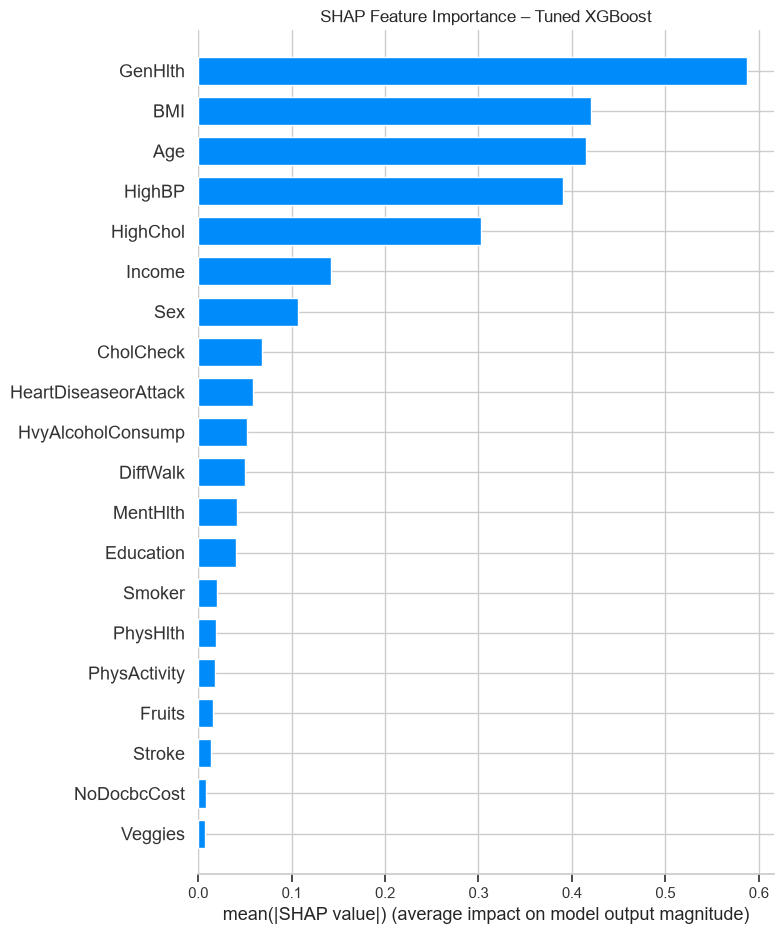

In [5]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance – Tuned XGBoost")
plt.tight_layout()
plt.show()

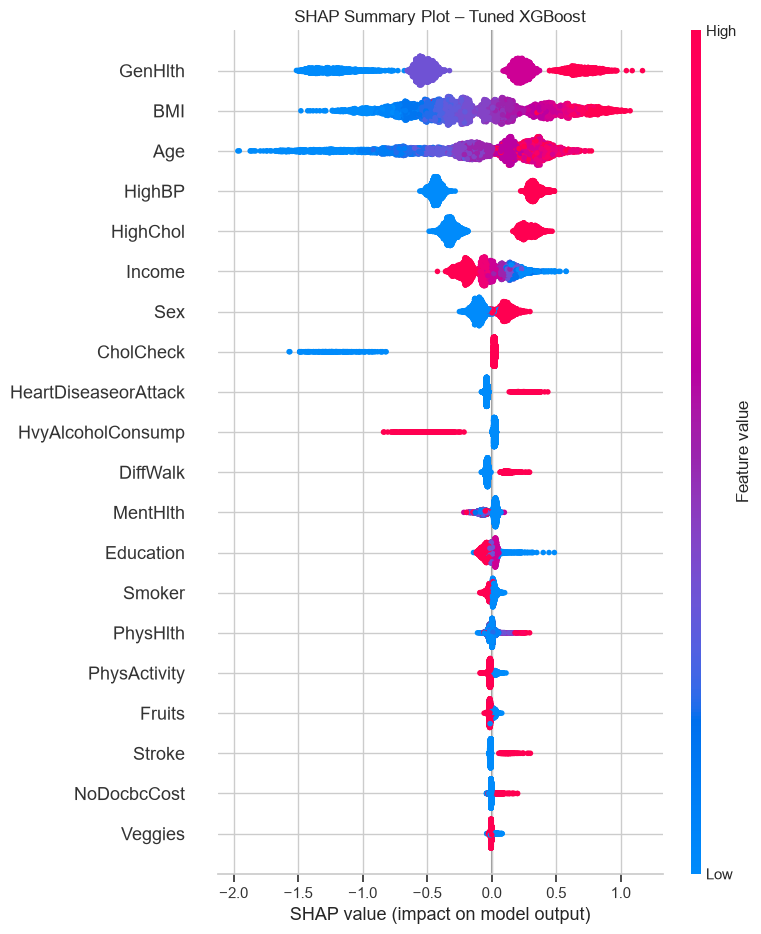

In [6]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.title("SHAP Summary Plot – Tuned XGBoost")
plt.tight_layout()
plt.show()

In [7]:
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(shap_importance.to_string(index=False))

             feature  mean_abs_shap
             GenHlth       0.586954
                 BMI       0.420559
                 Age       0.414554
              HighBP       0.390176
            HighChol       0.303006
              Income       0.142042
                 Sex       0.107018
           CholCheck       0.068638
HeartDiseaseorAttack       0.058236
   HvyAlcoholConsump       0.051756
            DiffWalk       0.050309
            MentHlth       0.041880
           Education       0.040882
              Smoker       0.019775
            PhysHlth       0.019067
        PhysActivity       0.018169
              Fruits       0.015881
              Stroke       0.013769
         NoDocbcCost       0.008292
             Veggies       0.007141
       AnyHealthcare       0.004909


In [8]:
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "xgb_importance": model.feature_importances_
})

comparison = (
    xgb_importance
    .merge(shap_importance, on="feature")
    .sort_values("mean_abs_shap", ascending=False)
)

print(comparison.to_string(index=False))

             feature  xgb_importance  mean_abs_shap
             GenHlth        0.148113       0.586954
                 BMI        0.049238       0.420559
                 Age        0.050328       0.414554
              HighBP        0.421067       0.390176
            HighChol        0.104815       0.303006
              Income        0.017127       0.142042
                 Sex        0.013916       0.107018
           CholCheck        0.022675       0.068638
HeartDiseaseorAttack        0.024023       0.058236
   HvyAlcoholConsump        0.022059       0.051756
            DiffWalk        0.083403       0.050309
            MentHlth        0.003560       0.041880
           Education        0.005880       0.040882
              Smoker        0.003939       0.019775
            PhysHlth        0.006126       0.019067
        PhysActivity        0.005280       0.018169
              Fruits        0.003313       0.015881
              Stroke        0.005150       0.013769
         NoD

In [9]:
sample_index = 0

X_person = X_test.iloc[[sample_index]]

actual = y_test.iloc[sample_index]
prediction = model.predict(X_person)[0]
probability = model.predict_proba(X_person)[0, 1]

print("Actual class     :", actual)
print("Predicted class  :", prediction)
print("Probability class 1:", round(probability, 4))

Actual class     : 0
Predicted class  : 1
Probability class 1: 0.6307


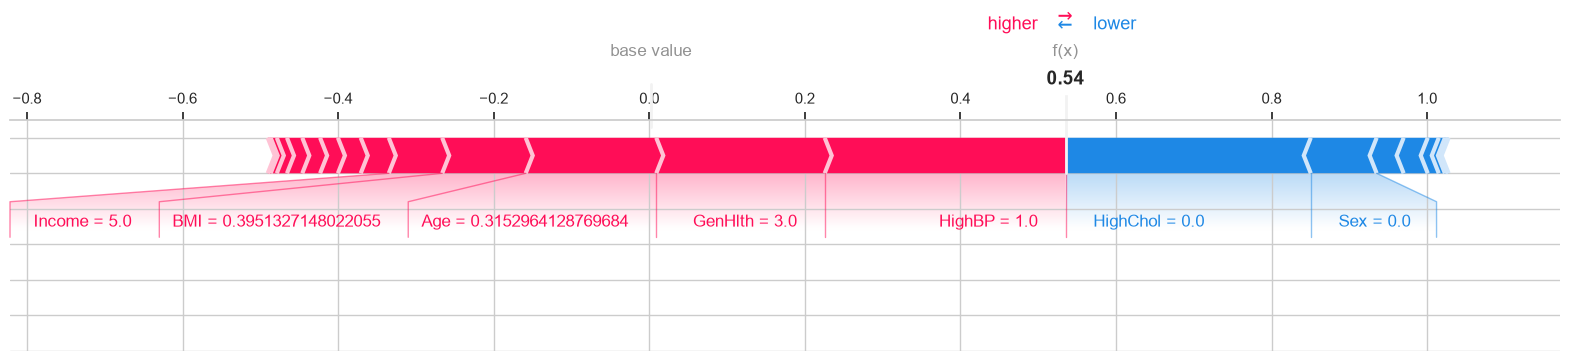

<Figure size 640x480 with 0 Axes>

In [10]:
person_shap = explainer.shap_values(X_person)

shap.force_plot(
    explainer.expected_value,
    person_shap[0],
    X_person.iloc[0],
    matplotlib=True
)

plt.tight_layout()
plt.show()

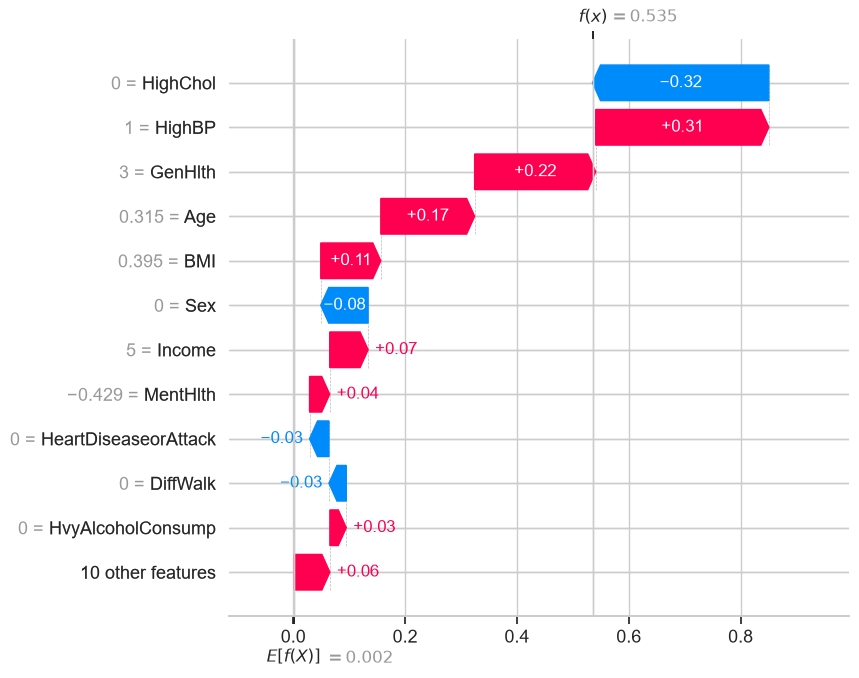

In [11]:
person_explanation = shap.Explanation(
    values=person_shap[0],
    base_values=explainer.expected_value,
    data=X_person.iloc[0].values,
    feature_names=X_person.columns
)

shap.plots.waterfall(person_explanation, max_display=12)

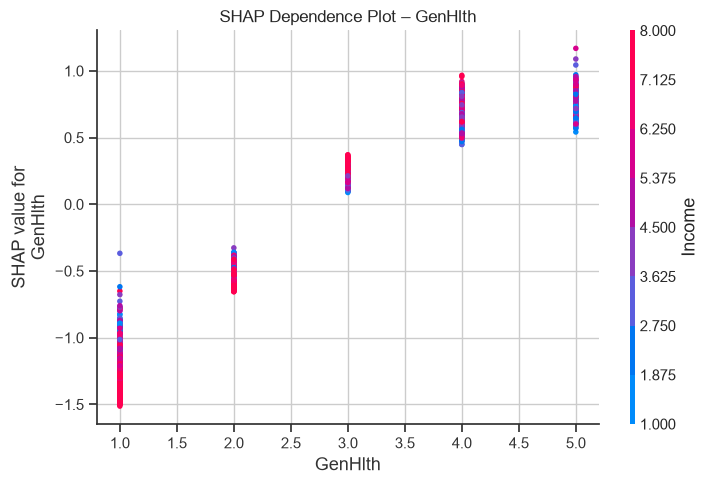

In [13]:
# Look at how GenHlth affects the model prediction

feature_index = X_shap.columns.get_loc("GenHlth")

shap.dependence_plot(
    feature_index,
    shap_values,
    X_shap,
    show=False
)

plt.title("SHAP Dependence Plot – GenHlth")
plt.tight_layout()
plt.show()